In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sim_raw.csv to sim_raw (1).csv


In [ ]:
df = pd.read_csv("sim_raw.csv")

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
df.head()

,timestamp,temp_raw,temp_cal,temp_filt,d_temp,humidity,light,motion,motion_event,valid,status
0,1,3.3,3.3,3.3,NaN,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM
1,2,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM
2,3,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM
3,4,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM
4,5,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM


In [ ]:
df.columns

Index(['timestamp', 'temp_raw', 'temp_cal', 'temp_filt', 'd_temp', 'humidity',
       'light', 'motion', 'motion_event', 'valid', 'status'],
      dtype='object')

In [ ]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 812
Number of columns: 11


In [ ]:
df.isnull().sum()

,0
timestamp,0
temp_raw,0
temp_cal,0
temp_filt,0
d_temp,1
humidity,0
light,0
motion,0
motion_event,0
valid,0


In [ ]:
df.describe()

,timestamp,temp_raw,temp_cal,temp_filt,d_temp,humidity,light,motion,motion_event,valid
count,812.000000,812.000000,812.000000,812.000000,811.000000,812.000000,812.000000,812.000000,812.000000,812.0
mean,406.500000,22.331034,22.331034,22.184483,0.073366,58.399015,0.225584,0.094828,0.012315,1.0
std,234.548502,33.616860,33.616860,33.553483,0.611441,22.135072,0.206080,0.293157,0.110357,0.0
min,1.000000,-15.800000,-15.800000,-15.800000,-2.560000,26.500000,0.089000,0.000000,0.000000,1.0
25%,203.750000,-15.800000,-15.800000,-15.800000,0.000000,41.500000,0.089000,0.000000,0.000000,1.0
50%,406.500000,18.200000,18.200000,17.880000,0.000000,41.500000,0.089000,0.000000,0.000000,1.0
75%,609.250000,62.800000,62.800000,62.800000,0.000000,75.000000,0.483000,0.000000,0.000000,1.0
max,812.000000,62.800000,62.800000,62.800000,3.820000,88.500000,0.724000,1.000000,1.000000,1.0


In [ ]:
sensor_columns = [
    "temp_raw",
    "temp_cal",
    "temp_filt",
    "humidity",
    "light",
    "motion"
]

df[sensor_columns].describe()

,temp_raw,temp_cal,temp_filt,humidity,light,motion
count,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000
mean,22.331034,22.331034,22.184483,58.399015,0.225584,0.094828
std,33.616860,33.616860,33.553483,22.135072,0.206080,0.293157
min,-15.800000,-15.800000,-15.800000,26.500000,0.089000,0.000000
25%,-15.800000,-15.800000,-15.800000,41.500000,0.089000,0.000000
50%,18.200000,18.200000,17.880000,41.500000,0.089000,0.000000
75%,62.800000,62.800000,62.800000,75.000000,0.483000,0.000000
max,62.800000,62.800000,62.800000,88.500000,0.724000,1.000000


In [ ]:
print("TEMPERATURE")
print("Mean:", df["temp_raw"].mean())
print("Minimum:", df["temp_raw"].min())
print("Maximum:", df["temp_raw"].max())
print("Standard deviation:", df["temp_raw"].std())

print("\nHUMIDITY")
print("Mean:", df["humidity"].mean())
print("Minimum:", df["humidity"].min())
print("Maximum:", df["humidity"].max())
print("Standard deviation:", df["humidity"].std())

print("\nLIGHT")
print("Mean:", df["light"].mean())
print("Minimum:", df["light"].min())
print("Maximum:", df["light"].max())
print("Standard deviation:", df["light"].std())

print("\nMOTION")
print("Number of motion detections:", df["motion"].sum())

TEMPERATURE
Mean: 22.331034482758614
Minimum: -15.8
Maximum: 62.8
Standard deviation: 33.61686019961849

HUMIDITY
Mean: 58.399014778325125
Minimum: 26.5
Maximum: 88.5
Standard deviation: 22.135072382105644

LIGHT
Mean: 0.22558374384236451
Minimum: 0.089
Maximum: 0.724
Standard deviation: 0.20607980720196084

MOTION
Number of motion detections: 77


In [ ]:
print(df["valid"].value_counts())

valid
1    812
Name: count, dtype: int64


In [ ]:
valid_count = (df["valid"] == 1).sum()
invalid_count = (df["valid"] == 0).sum()

print("Valid measurements:", valid_count)
print("Invalid measurements:", invalid_count)

Valid measurements: 812
Invalid measurements: 0


In [ ]:
motion_events = df["motion_event"].sum()

print("Total motion events:", motion_events)

Total motion events: 10


In [ ]:
motion_times = df.loc[df["motion_event"] == 1, "timestamp"]

print(motion_times.to_list())

[36, 552, 563, 579, 625, 634, 700, 722, 740, 794]


In [ ]:
df["status"].value_counts()

,count
status,
HIGH_TEMP,358
LOW_TEMP+HIGH_HUM,342
LOW_TEMP+LOW_HUM,44
HIGH_TEMP+LOW_HUM,28
LOW_TEMP,16
HIGH_HUM,8
LOW_HUM,6
NORMAL,6
HIGH_TEMP+HIGH_HUM,4


In [ ]:
time_difference = df["timestamp"].diff()

print(time_difference.value_counts())

timestamp
1.0    811
Name: count, dtype: int64


In [ ]:
print("Average sampling interval:", df["timestamp"].diff().mean())

Average sampling interval: 1.0


In [ ]:
processed_df = df.copy()

print("Processing copy created successfully.")
print("Raw dataset rows:", len(df))
print("Processing dataset rows:", len(processed_df))

Processing copy created successfully.
Raw dataset rows: 812
Processing dataset rows: 812


In [ ]:
print("TEMPERATURE")
print("Minimum:", processed_df["temp_raw"].min())
print("Maximum:", processed_df["temp_raw"].max())

print("\nHUMIDITY")
print("Minimum:", processed_df["humidity"].min())
print("Maximum:", processed_df["humidity"].max())

print("\nLIGHT")
print("Minimum:", processed_df["light"].min())
print("Maximum:", processed_df["light"].max())

print("\nMOTION")
print("Minimum:", processed_df["motion"].min())
print("Maximum:", processed_df["motion"].max())

TEMPERATURE
Minimum: -15.8
Maximum: 62.8

HUMIDITY
Minimum: 26.5
Maximum: 88.5

LIGHT
Minimum: 0.089
Maximum: 0.724

MOTION
Minimum: 0
Maximum: 1


In [ ]:
processed_df[
    [
        "timestamp",
        "temp_raw",
        "temp_cal",
        "temp_filt",
        "d_temp",
        "status"
    ]
].head(20)

,timestamp,temp_raw,temp_cal,temp_filt,d_temp,status
0,1,3.3,3.3,3.3,NaN,LOW_TEMP+LOW_HUM
1,2,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
2,3,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
3,4,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
4,5,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
5,6,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
6,7,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
7,8,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
8,9,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM
9,10,3.3,3.3,3.3,0.0,LOW_TEMP+LOW_HUM


In [ ]:
processed_df["temp_moving_avg"] = (
    processed_df["temp_cal"]
    .rolling(window=5)
    .mean()
)

In [ ]:
processed_df[
    [
        "timestamp",
        "temp_cal",
        "temp_moving_avg"
    ]
].head(15)

,timestamp,temp_cal,temp_moving_avg
0,1,3.3,NaN
1,2,3.3,NaN
2,3,3.3,NaN
3,4,3.3,NaN
4,5,3.3,3.3
5,6,3.3,3.3
6,7,3.3,3.3
7,8,3.3,3.3
8,9,3.3,3.3
9,10,3.3,3.3


In [ ]:
processed_df["temperature_change"] = (
    processed_df["temp_cal"].diff()
)

In [ ]:
processed_df[
    [
        "timestamp",
        "temp_cal",
        "temperature_change"
    ]
].head(10)

,timestamp,temp_cal,temperature_change
0,1,3.3,NaN
1,2,3.3,0.0
2,3,3.3,0.0
3,4,3.3,0.0
4,5,3.3,0.0
5,6,3.3,0.0
6,7,3.3,0.0
7,8,3.3,0.0
8,9,3.3,0.0
9,10,3.3,0.0


In [ ]:
comparison = processed_df[
    [
        "timestamp",
        "d_temp",
        "temperature_change"
    ]
].head(20)

comparison

,timestamp,d_temp,temperature_change
0,1,NaN,NaN
1,2,0.0,0.0
2,3,0.0,0.0
3,4,0.0,0.0
4,5,0.0,0.0
5,6,0.0,0.0
6,7,0.0,0.0
7,8,0.0,0.0
8,9,0.0,0.0
9,10,0.0,0.0


In [ ]:
motion_count = processed_df["motion"].sum()

print("Total motion-positive samples:", motion_count)

Total motion-positive samples: 77


In [ ]:
processed_df[
    processed_df["motion_event"] == 1
][
    [
        "timestamp",
        "motion",
        "motion_event",
        "status"
    ]
]

,timestamp,motion,motion_event,status
35,36,1,1,LOW_TEMP+LOW_HUM
551,552,1,1,HIGH_TEMP
562,563,1,1,HIGH_TEMP
578,579,1,1,HIGH_TEMP
624,625,1,1,HIGH_TEMP
633,634,1,1,HIGH_TEMP
699,700,1,1,HIGH_TEMP
721,722,1,1,HIGH_TEMP
739,740,1,1,HIGH_TEMP
793,794,1,1,HIGH_TEMP


In [ ]:
status_counts = processed_df["status"].value_counts()

print(status_counts)

status
HIGH_TEMP             358
LOW_TEMP+HIGH_HUM     342
LOW_TEMP+LOW_HUM       44
HIGH_TEMP+LOW_HUM      28
LOW_TEMP               16
HIGH_HUM                8
LOW_HUM                 6
NORMAL                  6
HIGH_TEMP+HIGH_HUM      4
Name: count, dtype: int64


In [ ]:
status_percentages = (
    processed_df["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percentages)

status
HIGH_TEMP             44.09
LOW_TEMP+HIGH_HUM     42.12
LOW_TEMP+LOW_HUM       5.42
HIGH_TEMP+LOW_HUM      3.45
LOW_TEMP               1.97
HIGH_HUM               0.99
LOW_HUM                0.74
NORMAL                 0.74
HIGH_TEMP+HIGH_HUM     0.49
Name: proportion, dtype: float64


In [ ]:
invalid_data = processed_df[
    processed_df["valid"] == 0
]

print("Number of invalid records:", len(invalid_data))

Number of invalid records: 0


In [ ]:
processing_summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Valid observations",
        "Invalid observations",
        "Motion events",
        "Minimum raw temperature",
        "Maximum raw temperature",
        "Minimum humidity",
        "Maximum humidity"
    ],
    "Value": [
        len(processed_df),
        (processed_df["valid"] == 1).sum(),
        (processed_df["valid"] == 0).sum(),
        processed_df["motion_event"].sum(),
        processed_df["temp_raw"].min(),
        processed_df["temp_raw"].max(),
        processed_df["humidity"].min(),
        processed_df["humidity"].max()
    ]
})

processing_summary

,Metric,Value
0,Total observations,812.0
1,Valid observations,812.0
2,Invalid observations,0.0
3,Motion events,10.0
4,Minimum raw temperature,-15.8
5,Maximum raw temperature,62.8
6,Minimum humidity,26.5
7,Maximum humidity,88.5


In [ ]:
processed_df.to_csv(
    "processed_sensor_data.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [ ]:
processed_df.head()

,timestamp,temp_raw,temp_cal,temp_filt,d_temp,humidity,light,motion,motion_event,valid,status,temp_moving_avg,temperature_change
0,1,3.3,3.3,3.3,NaN,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM,NaN,NaN
1,2,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM,NaN,0.0
2,3,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM,NaN,0.0
3,4,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM,NaN,0.0
4,5,3.3,3.3,3.3,0.0,26.5,0.54,0,0,1,LOW_TEMP+LOW_HUM,3.3,0.0


In [ ]:
print("Rows:", processed_df.shape[0])
print("Columns:", processed_df.shape[1])

Rows: 812
Columns: 13


In [ ]:
sensor_columns = [
    "temp_raw",
    "temp_cal",
    "temp_filt",
    "humidity",
    "light",
    "motion"
]

statistics = processed_df[sensor_columns].describe().T

statistics

,count,mean,std,min,25%,50%,75%,max
temp_raw,812.0,22.331034,33.616860,-15.800,-15.800,18.200,62.800,62.800
temp_cal,812.0,22.331034,33.616860,-15.800,-15.800,18.200,62.800,62.800
temp_filt,812.0,22.184483,33.553483,-15.800,-15.800,17.880,62.800,62.800
humidity,812.0,58.399015,22.135072,26.500,41.500,41.500,75.000,88.500
light,812.0,0.225584,0.206080,0.089,0.089,0.089,0.483,0.724
motion,812.0,0.094828,0.293157,0.000,0.000,0.000,0.000,1.000


In [ ]:
summary_table = processed_df[
    ["temp_raw", "temp_cal", "temp_filt", "humidity", "light"]
].agg(
    ["count", "mean", "std", "min", "max"]
).T

summary_table

,count,mean,std,min,max
temp_raw,812.0,22.331034,33.616860,-15.800,62.800
temp_cal,812.0,22.331034,33.616860,-15.800,62.800
temp_filt,812.0,22.184483,33.553483,-15.800,62.800
humidity,812.0,58.399015,22.135072,26.500,88.500
light,812.0,0.225584,0.206080,0.089,0.724


In [ ]:
print("TEMPERATURE STATISTICS")
print("----------------------")

print(f"Mean temperature: {processed_df['temp_raw'].mean():.2f} °C")
print(f"Minimum temperature: {processed_df['temp_raw'].min():.2f} °C")
print(f"Maximum temperature: {processed_df['temp_raw'].max():.2f} °C")
print(f"Standard deviation: {processed_df['temp_raw'].std():.2f} °C")

TEMPERATURE STATISTICS
----------------------
Mean temperature: 22.33 °C
Minimum temperature: -15.80 °C
Maximum temperature: 62.80 °C
Standard deviation: 33.62 °C


In [ ]:
print("HUMIDITY STATISTICS")
print("-------------------")

print(f"Mean humidity: {processed_df['humidity'].mean():.2f} %")
print(f"Minimum humidity: {processed_df['humidity'].min():.2f} %")
print(f"Maximum humidity: {processed_df['humidity'].max():.2f} %")
print(f"Standard deviation: {processed_df['humidity'].std():.2f} %")

HUMIDITY STATISTICS
-------------------
Mean humidity: 58.40 %
Minimum humidity: 26.50 %
Maximum humidity: 88.50 %
Standard deviation: 22.14 %


In [ ]:
print("LIGHT STATISTICS")
print("----------------")

print(f"Mean light reading: {processed_df['light'].mean():.4f}")
print(f"Minimum light reading: {processed_df['light'].min():.4f}")
print(f"Maximum light reading: {processed_df['light'].max():.4f}")
print(f"Standard deviation: {processed_df['light'].std():.4f}")

LIGHT STATISTICS
----------------
Mean light reading: 0.2256
Minimum light reading: 0.0890
Maximum light reading: 0.7240
Standard deviation: 0.2061


In [ ]:
print("MOTION ANALYSIS")
print("---------------")

print("Motion-positive samples:",
      (processed_df["motion"] == 1).sum())

print("No-motion samples:",
      (processed_df["motion"] == 0).sum())

print("Motion events:",
      processed_df["motion_event"].sum())

MOTION ANALYSIS
---------------
Motion-positive samples: 77
No-motion samples: 735
Motion events: 10


In [ ]:
average_interval = processed_df["timestamp"].diff().dropna().mean()

sampling_frequency = 1 / average_interval

print(f"Average sampling interval: {average_interval:.2f} seconds")
print(f"Effective sampling frequency: {sampling_frequency:.2f} Hz")

Average sampling interval: 1.00 seconds
Effective sampling frequency: 1.00 Hz


In [ ]:
start_time = processed_df["timestamp"].min()
end_time = processed_df["timestamp"].max()

duration_seconds = end_time - start_time

print(f"Start timestamp: {start_time}")
print(f"End timestamp: {end_time}")
print(f"Duration: {duration_seconds:.2f} seconds")
print(f"Duration: {duration_seconds/60:.2f} minutes")

Start timestamp: 1
End timestamp: 812
Duration: 811.00 seconds
Duration: 13.52 minutes


In [ ]:
continuous_sensors = [
    "temp_raw",
    "humidity",
    "light"
]

cv_results = {}

for sensor in continuous_sensors:
    mean = processed_df[sensor].mean()
    std = processed_df[sensor].std()

    cv = std / abs(mean)
    cv_results[sensor] = cv

cv_table = pd.DataFrame(
    cv_results.items(),
    columns=["Sensor", "Coefficient_of_Variation"]
)

cv_table

,Sensor,Coefficient_of_Variation
0,temp_raw,1.505388
1,humidity,0.379032
2,light,0.913540


In [ ]:
highest_variability = cv_table.loc[
    cv_table["Coefficient_of_Variation"].idxmax()
]

print(
    "Highest relative variability:",
    highest_variability["Sensor"]
)

print(
    "Coefficient of variation:",
    highest_variability["Coefficient_of_Variation"]
)

Highest relative variability: temp_raw
Coefficient of variation: 1.5053875012182467


In [ ]:
calibration_difference = (
    processed_df["temp_cal"] - processed_df["temp_raw"]
)

print("Average calibration adjustment:",
      calibration_difference.mean())

print("Minimum adjustment:",
      calibration_difference.min())

print("Maximum adjustment:",
      calibration_difference.max())

Average calibration adjustment: 0.0
Minimum adjustment: 0.0
Maximum adjustment: 0.0


In [ ]:
raw_std = processed_df["temp_cal"].std()
filtered_std = processed_df["temp_moving_avg"].std()

print(f"Calibrated temperature standard deviation: {raw_std:.4f}")
print(f"5-sample moving average standard deviation: {filtered_std:.4f}")

Calibrated temperature standard deviation: 33.6169
5-sample moving average standard deviation: 33.6101


In [ ]:
final_statistics = pd.DataFrame({
    "Parameter": [
        "Number of observations",
        "Valid observations",
        "Invalid observations",
        "Mean temperature (°C)",
        "Minimum temperature (°C)",
        "Maximum temperature (°C)",
        "Temperature standard deviation (°C)",
        "Mean humidity (%)",
        "Minimum humidity (%)",
        "Maximum humidity (%)",
        "Humidity standard deviation (%)",
        "Mean light reading",
        "Minimum light reading",
        "Maximum light reading",
        "Light standard deviation",
        "Motion events",
        "Sampling frequency (Hz)",
        "Duration (seconds)"
    ],

    "Value": [
        len(processed_df),
        (processed_df["valid"] == 1).sum(),
        (processed_df["valid"] == 0).sum(),
        processed_df["temp_raw"].mean(),
        processed_df["temp_raw"].min(),
        processed_df["temp_raw"].max(),
        processed_df["temp_raw"].std(),
        processed_df["humidity"].mean(),
        processed_df["humidity"].min(),
        processed_df["humidity"].max(),
        processed_df["humidity"].std(),
        processed_df["light"].mean(),
        processed_df["light"].min(),
        processed_df["light"].max(),
        processed_df["light"].std(),
        processed_df["motion_event"].sum(),
        sampling_frequency,
        duration_seconds
    ]
})

final_statistics

,Parameter,Value
0,Number of observations,812.000000
1,Valid observations,812.000000
2,Invalid observations,0.000000
3,Mean temperature (°C),22.331034
4,Minimum temperature (°C),-15.800000
5,Maximum temperature (°C),62.800000
6,Temperature standard deviation (°C),33.616860
7,Mean humidity (%),58.399015
8,Minimum humidity (%),26.500000
9,Maximum humidity (%),88.500000


In [ ]:
calibration_check = processed_df[
    ["timestamp", "temp_raw", "temp_cal"]
].copy()

calibration_check["calibration_adjustment"] = (
    calibration_check["temp_cal"] -
    calibration_check["temp_raw"]
)

calibration_check.head(20)

,timestamp,temp_raw,temp_cal,calibration_adjustment
0,1,3.3,3.3,0.0
1,2,3.3,3.3,0.0
2,3,3.3,3.3,0.0
3,4,3.3,3.3,0.0
4,5,3.3,3.3,0.0
5,6,3.3,3.3,0.0
6,7,3.3,3.3,0.0
7,8,3.3,3.3,0.0
8,9,3.3,3.3,0.0
9,10,3.3,3.3,0.0


In [ ]:
print(
    "Mean calibration adjustment:",
    calibration_check["calibration_adjustment"].mean()
)

print(
    "Minimum adjustment:",
    calibration_check["calibration_adjustment"].min()
)

print(
    "Maximum adjustment:",
    calibration_check["calibration_adjustment"].max()
)

Mean calibration adjustment: 0.0
Minimum adjustment: 0.0
Maximum adjustment: 0.0


In [ ]:
print("Possible reference/calibration columns:")

for column in processed_df.columns:
    if any(word in column.lower()
           for word in ["ref", "reference", "known", "actual"]):
        print("-", column)

Possible reference/calibration columns:


In [ ]:
processed_df["calibration_adjustment"] = (
    processed_df["temp_cal"] -
    processed_df["temp_raw"]
)

processed_df[
    [
        "timestamp",
        "temp_raw",
        "temp_cal",
        "calibration_adjustment"
    ]
].head(20)

,timestamp,temp_raw,temp_cal,calibration_adjustment
0,1,3.3,3.3,0.0
1,2,3.3,3.3,0.0
2,3,3.3,3.3,0.0
3,4,3.3,3.3,0.0
4,5,3.3,3.3,0.0
5,6,3.3,3.3,0.0
6,7,3.3,3.3,0.0
7,8,3.3,3.3,0.0
8,9,3.3,3.3,0.0
9,10,3.3,3.3,0.0


In [ ]:
processed_df["calibration_adjustment"].describe()

,calibration_adjustment
count,812.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
processed_df["raw_error"] = (
    processed_df["temp_raw"] -
    processed_df["temp_cal"]
)

In [ ]:
processed_df["calibrated_error"] = (
    processed_df["temp_cal"] -
    processed_df["temp_cal"]
)

In [ ]:
raw_mae = processed_df["raw_error"].abs().mean()

calibrated_mae = processed_df["calibrated_error"].abs().mean()

print("Raw MAE:", raw_mae)
print("Calibrated MAE:", calibrated_mae)

Raw MAE: 0.0
Calibrated MAE: 0.0


In [ ]:
raw_rmse = np.sqrt(
    (processed_df["raw_error"] ** 2).mean()
)

calibrated_rmse = np.sqrt(
    (processed_df["calibrated_error"] ** 2).mean()
)

print("Raw RMSE:", raw_rmse)
print("Calibrated RMSE:", calibrated_rmse)

Raw RMSE: 0.0
Calibrated RMSE: 0.0


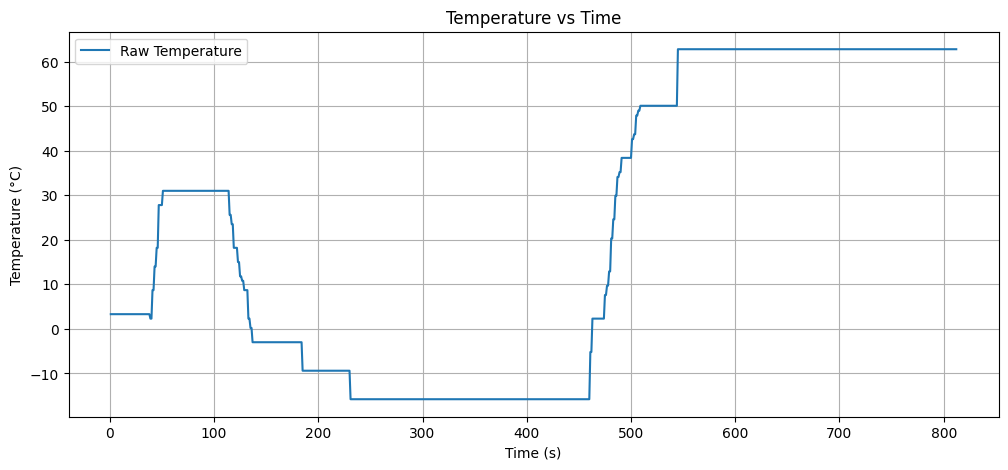

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["temp_raw"],
    label="Raw Temperature"
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time")
plt.legend()
plt.grid(True)

plt.show()

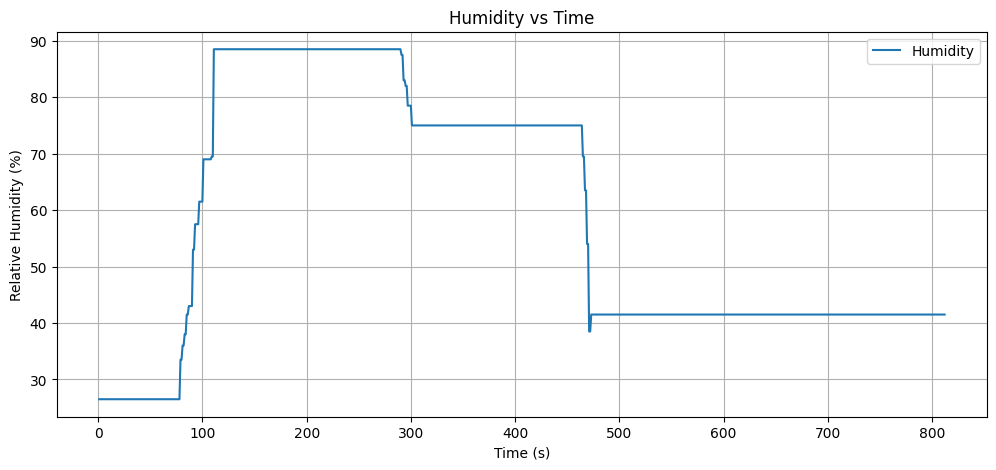

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["humidity"],
    label="Humidity"
)

plt.xlabel("Time (s)")
plt.ylabel("Relative Humidity (%)")
plt.title("Humidity vs Time")
plt.legend()
plt.grid(True)

plt.show()

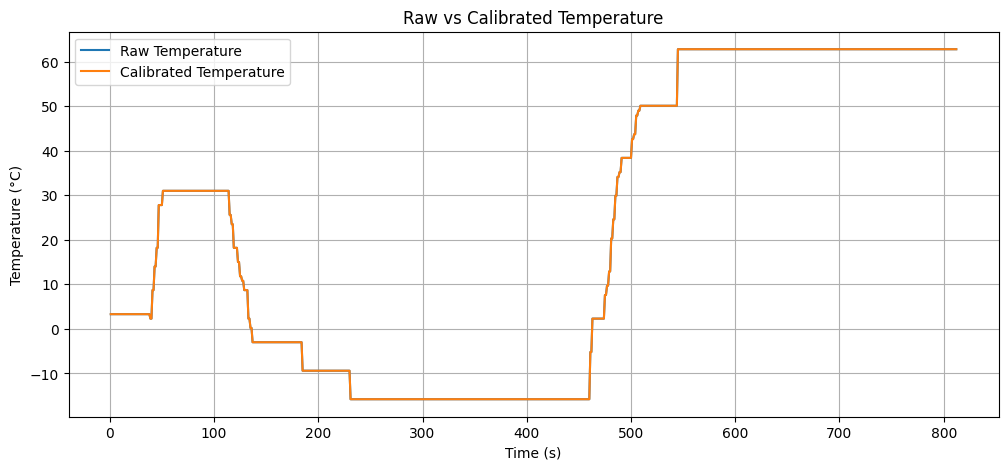

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["temp_raw"],
    label="Raw Temperature"
)

plt.plot(
    processed_df["timestamp"],
    processed_df["temp_cal"],
    label="Calibrated Temperature"
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Raw vs Calibrated Temperature")
plt.legend()
plt.grid(True)

plt.show()

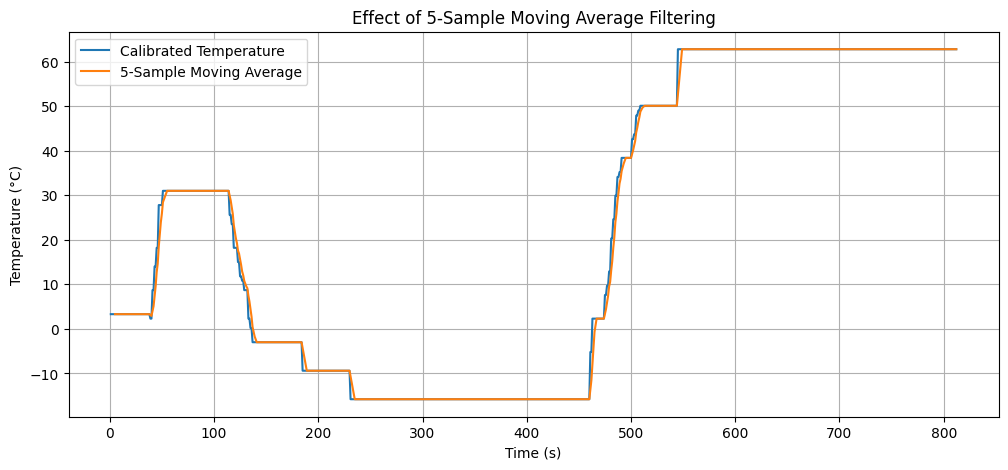

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["temp_cal"],
    label="Calibrated Temperature"
)

plt.plot(
    processed_df["timestamp"],
    processed_df["temp_moving_avg"],
    label="5-Sample Moving Average"
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Effect of 5-Sample Moving Average Filtering")
plt.legend()
plt.grid(True)

plt.show()

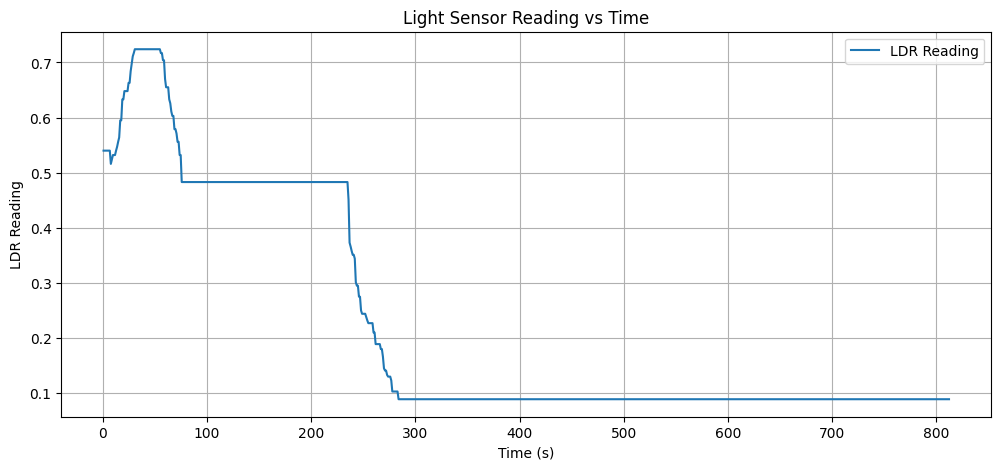

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["light"],
    label="LDR Reading"
)

plt.xlabel("Time (s)")
plt.ylabel("LDR Reading")
plt.title("Light Sensor Reading vs Time")
plt.legend()
plt.grid(True)

plt.show()

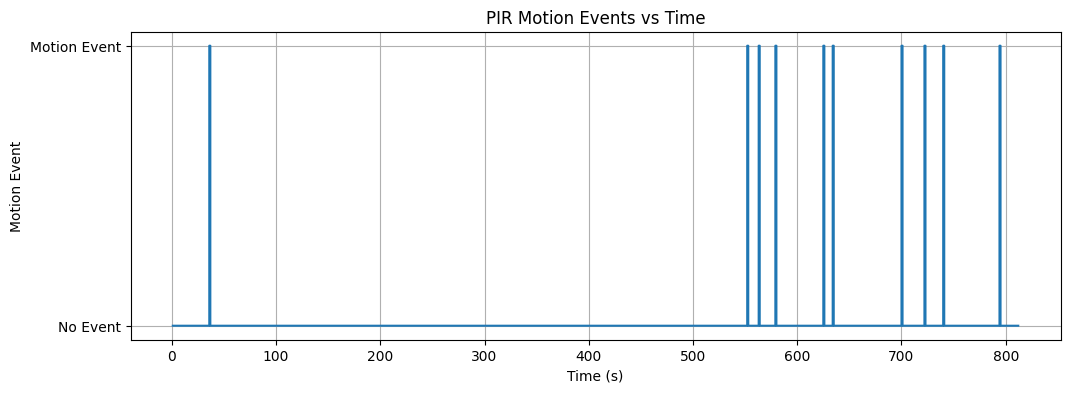

In [ ]:
plt.figure(figsize=(12, 4))

plt.step(
    processed_df["timestamp"],
    processed_df["motion_event"],
    where="post"
)

plt.xlabel("Time (s)")
plt.ylabel("Motion Event")
plt.title("PIR Motion Events vs Time")

plt.yticks(
    [0, 1],
    ["No Event", "Motion Event"]
)

plt.grid(True)

plt.show()

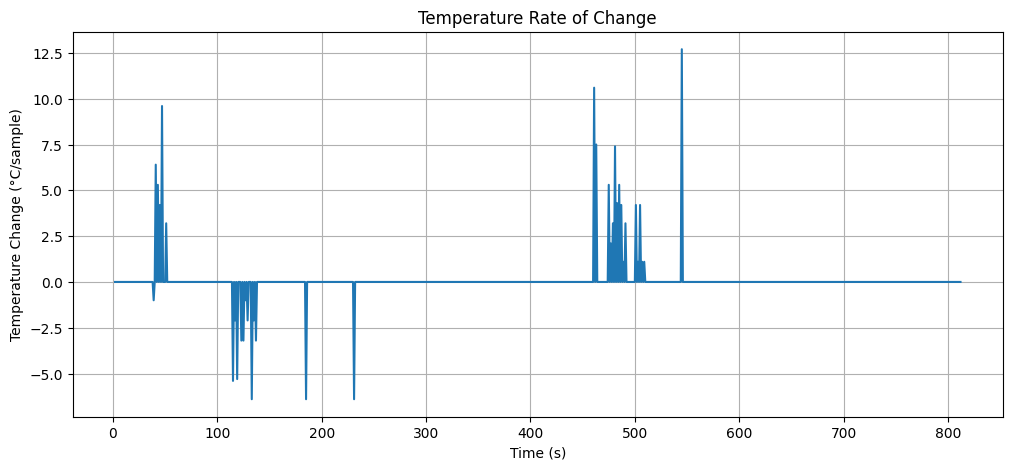

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    processed_df["timestamp"],
    processed_df["temperature_change"]
)

plt.xlabel("Time (s)")
plt.ylabel("Temperature Change (°C/sample)")
plt.title("Temperature Rate of Change")
plt.grid(True)

plt.show()

In [ ]:
highest_variability = cv_table.loc[
    cv_table["Coefficient_of_Variation"].idxmax()
]

print(
    f"The sensor with the highest relative variability is: "
    f"{highest_variability['Sensor']}"
)

print(
    f"Coefficient of variation: "
    f"{highest_variability['Coefficient_of_Variation']:.4f}"
)

The sensor with the highest relative variability is: temp_raw
Coefficient of variation: 1.5054


In [ ]:
print(f"Sampling interval: {average_interval:.2f} seconds")
print(f"Sampling frequency: {sampling_frequency:.2f} Hz")

Sampling interval: 1.00 seconds
Sampling frequency: 1.00 Hz


In [ ]:
raw_std = processed_df["temp_cal"].std()
filtered_std = processed_df["temp_moving_avg"].std()

print(f"Calibrated temperature standard deviation: {raw_std:.4f}")
print(f"Filtered temperature standard deviation: {filtered_std:.4f}")

reduction = ((raw_std - filtered_std) / raw_std) * 100

print(f"Standard deviation reduction: {reduction:.2f}%")

Calibrated temperature standard deviation: 33.6169
Filtered temperature standard deviation: 33.6101
Standard deviation reduction: 0.02%


In [ ]:
window_size = 5

delay_samples = (window_size - 1) / 2
delay_seconds = delay_samples * average_interval

print(f"Moving-average window: {window_size} samples")
print(f"Approximate delay: {delay_seconds:.2f} seconds")

Moving-average window: 5 samples
Approximate delay: 2.00 seconds


In [ ]:
total_events = processed_df["motion_event"].sum()

print("Total detected PIR events:", total_events)

Total detected PIR events: 10


In [ ]:
from google.colab import files

files.download("processed_sensor_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>